# RSI-2 with Volatility Regime Filter (v3)

## The Lesson from v1 & v2

Fundamental filters (Piotroski, Altman Z, Beneish M) don't help RSI-2 because:
- The strategy's losses aren't caused by trading bad stocks (all 20 tickers lost money)
- Quarterly accounting data can't predict 2-day price reversals (frequency mismatch)
- The real failure mode is **regime**: RSI-2 loses when the market is trending/volatile

## The New Hypothesis

**Mean reversion works in low-volatility, range-bound regimes. It fails in trending or volatile regimes.**

Instead of filtering WHAT to trade, filter WHEN to trade:
- **Trade** when 20-day realized volatility is below its 6-month median (calm market)
- **Sit out** when volatility spikes above median (trending/crash/news-driven)

This is daily, forward-looking, and addresses the actual mechanism of failure.

## Also: Fixed Screener.in Scraper

v2's scraper only read the top-card ratios (`#top-ratios`). The fix: parse the actual financial tables (`#profit-loss`, `#balance-sheet`, `#cash-flow`) to compute a proper Piotroski F-Score from raw financials. Included here for completeness but the regime filter is the real test.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import time

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Fixed Screener.in Scraper

**What was broken in v2:** only parsed `#top-ratios li` (ROE, ROCE, P/E — the summary card).

**The fix:** parse the actual financial data tables:
- `#profit-loss table` — Revenue, Net Profit, OPM%
- `#balance-sheet table` — Total Assets, Borrowings, Equity
- `#cash-flow table` — Operating CF, Free CF
- `#ratios table` — ROCE%, Debtor Days, Working Capital Days

From these raw numbers we compute a proper 9-point Piotroski F-Score.

In [2]:
HEADERS = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"}

def parse_screener_table(soup, section_id):
    """Parse a Screener.in financial table into a dict of {row_label: [values]}.
    Returns most recent 2 years of data."""
    section = soup.select_one(f'#{section_id}')
    if not section:
        return {}
    table = section.select_one('table')
    if not table:
        return {}
    
    data = {}
    for tr in table.select('tr'):
        cells = tr.select('td, th')
        if len(cells) < 3:
            continue
        label = cells[0].get_text(strip=True).rstrip('+')
        if not label or label.startswith('Mar') or label.startswith('TTM'):
            continue
        vals = []
        for c in cells[1:]:
            txt = c.get_text(strip=True).replace(',', '').replace('%', '')
            try:
                vals.append(float(txt))
            except ValueError:
                vals.append(None)
        if vals:
            data[label] = vals
    return data


def scrape_screener_full(symbol):
    """Scrape full financials from Screener.in and compute Piotroski F-Score.
    Returns dict with f_score, roe, revenue_growth, etc."""
    url = f"https://www.screener.in/company/{symbol}/consolidated/"
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)
        if r.status_code != 200:
            url = f"https://www.screener.in/company/{symbol}/"
            r = requests.get(url, headers=HEADERS, timeout=10)
            if r.status_code != 200:
                return None
    except Exception:
        return None
    
    soup = BeautifulSoup(r.text, 'html.parser')
    
    # Parse top-card for ROE/ROCE
    top = {}
    for li in soup.select('#top-ratios li'):
        name_el = li.select_one('.name')
        val_el = li.select_one('.value, .number')
        if name_el and val_el:
            name = name_el.get_text(strip=True)
            val = val_el.get_text(strip=True).replace(',', '').replace('%', '')
            try:
                top[name] = float(val)
            except ValueError:
                pass
    
    # Parse financial tables
    pl = parse_screener_table(soup, 'profit-loss')
    bs = parse_screener_table(soup, 'balance-sheet')
    cf = parse_screener_table(soup, 'cash-flow')
    
    if not pl or not bs:
        return None
    
    def get(table, key, idx=0, default=0):
        """Get value from table, latest year = last column (idx=-1), prev = idx=-2."""
        if key in table and table[key]:
            vals = [v for v in table[key] if v is not None]
            if len(vals) > abs(idx):
                return vals[idx]
        return default
    
    # Latest and previous year (last two columns)
    revenue = get(pl, 'Sales', -1)
    revenue_prev = get(pl, 'Sales', -2)
    net_profit = get(pl, 'Net Profit', -1)
    net_profit_prev = get(pl, 'Net Profit', -2)
    op_profit = get(pl, 'Operating Profit', -1)
    
    total_assets = get(bs, 'Total Assets', -1) or get(bs, 'Total Liabilities', -1)
    total_assets_prev = get(bs, 'Total Assets', -2) or get(bs, 'Total Liabilities', -2)
    borrowings = get(bs, 'Borrowings', -1)
    borrowings_prev = get(bs, 'Borrowings', -2)
    equity = get(bs, 'Reserves', -1) + get(bs, 'Equity Capital', -1)
    equity_prev = get(bs, 'Reserves', -2) + get(bs, 'Equity Capital', -2)
    
    op_cf = get(cf, 'Cash from Operating Activity', -1)
    op_cf_prev = get(cf, 'Cash from Operating Activity', -2)
    
    # Compute Piotroski F-Score (9 criteria)
    f_score = 0
    
    roa = net_profit / total_assets if total_assets else 0
    roa_prev = net_profit_prev / total_assets_prev if total_assets_prev else 0
    
    # 1. Positive ROA
    if roa > 0: f_score += 1
    # 2. Positive operating cash flow
    if op_cf > 0: f_score += 1
    # 3. Rising ROA
    if roa > roa_prev: f_score += 1
    # 4. Cash flow > Net Income (quality of earnings)
    if op_cf > net_profit: f_score += 1
    # 5. Decreasing leverage (borrowings/assets)
    lev = borrowings / total_assets if total_assets else 0
    lev_prev = borrowings_prev / total_assets_prev if total_assets_prev else 0
    if lev <= lev_prev: f_score += 1
    # 6. Improving current ratio (proxy: working capital positive)
    # Use equity growth as proxy since Screener doesn't split current/non-current
    if equity > equity_prev: f_score += 1
    # 7. No dilution (equity capital unchanged)
    eq_cap = get(bs, 'Equity Capital', -1)
    eq_cap_prev = get(bs, 'Equity Capital', -2)
    if eq_cap <= eq_cap_prev and eq_cap_prev > 0: f_score += 1
    # 8. Improving gross margin (use OPM as proxy)
    opm = op_profit / revenue if revenue else 0
    op_profit_prev = get(pl, 'Operating Profit', -2)
    opm_prev = op_profit_prev / revenue_prev if revenue_prev else 0
    if opm > opm_prev: f_score += 1
    # 9. Improving asset turnover
    at = revenue / total_assets if total_assets else 0
    at_prev = revenue_prev / total_assets_prev if total_assets_prev else 0
    if at > at_prev: f_score += 1
    
    roe = top.get('ROE', (net_profit / equity * 100) if equity else 0)
    roce = top.get('ROCE', 0)
    revenue_growth = ((revenue / revenue_prev) - 1) * 100 if revenue_prev else 0
    
    return {
        'f_score': f_score,
        'roe': round(float(roe), 1),
        'roce': round(float(roce), 1),
        'revenue_growth': round(float(revenue_growth), 1),
        'debt_to_assets': round(float(lev * 100), 1),
        'cf_positive': op_cf > 0,
        'source': 'screener.in',
    }

In [3]:
# Test the fixed scraper
TEST_TICKERS = ['RELIANCE', 'TCS', 'HDFCBANK', 'WIPRO', 'ITC']

print("Fixed Screener.in scraper test:")
print(f"{'Symbol':<12} {'F-Score':<8} {'ROE%':<7} {'ROCE%':<7} {'Rev Grw%':<9} {'D/A%':<6} {'CF+'}")
print("-" * 60)
for sym in TEST_TICKERS:
    result = scrape_screener_full(sym)
    if result:
        print(f"{sym:<12} {result['f_score']:<8} {result['roe']:<7} {result['roce']:<7} "
              f"{result['revenue_growth']:<9} {result['debt_to_assets']:<6} {result['cf_positive']}")
    else:
        print(f"{sym:<12} FAILED")
    time.sleep(1)

print("\nExpected: Reliance/TCS/HDFC should score 6-8 (strong companies).")
print("v2 scored them 0-3 because it only read the summary card.")

Fixed Screener.in scraper test:
Symbol       F-Score  ROE%    ROCE%   Rev Grw%  D/A%   CF+
------------------------------------------------------------
RELIANCE     7        8.9     10.3    9.7       18.5   True
TCS          6        51.8    63.0    4.6       6.2    True
HDFCBANK     5        13.8    7.0     0.0       0.0    True
WIPRO        5        15.5    17.9    4.0       14.3   True
ITC          4        29.3    38.9    4.7       2.6    True

Expected: Reliance/TCS/HDFC should score 6-8 (strong companies).
v2 scored them 0-3 because it only read the summary card.


## 3. The Regime Filter

**Core idea:** Mean reversion strategies profit when prices oscillate around a mean. They lose when prices trend persistently in one direction (up or down). Volatility is a proxy for trending behavior.

**Implementation:**
- Compute 20-day realized volatility (annualized std of daily returns)
- Compare to its own 126-day (6-month) rolling median
- **Low-vol regime** (vol < median): allow RSI-2 entries
- **High-vol regime** (vol >= median): no new entries, exit at next opportunity

**Why this should work:**
- High-vol periods = news/trends/crashes = dips don't revert, they continue
- Low-vol periods = range-bound = dips are noise and DO revert
- Daily frequency matches the strategy's holding period (2-5 days)

In [4]:
def realized_vol(prices, window=20):
    """20-day realized volatility, annualized."""
    returns = prices.pct_change()
    return returns.rolling(window).std() * np.sqrt(252)


def vol_regime(prices, vol_window=20, median_window=126):
    """Returns a boolean Series: True = low-vol (safe to trade), False = high-vol."""
    vol = realized_vol(prices, vol_window)
    vol_median = vol.rolling(median_window).median()
    return vol < vol_median


def rsi(s, p=2):
    d = s.diff(); g = d.clip(lower=0); l = -d.clip(upper=0)
    ag = g.ewm(alpha=1/p, adjust=False).mean()
    al = l.ewm(alpha=1/p, adjust=False).mean()
    return 100 - (100/(1 + ag/al.replace(0, np.nan)))


def cost():
    """Indian equity round-trip transaction cost."""
    return 0.001 + 0.0000345 + 0.18*0.0000345 + 0.00015 + 0.000001 + 0.0015


def load_price(ticker, start="2020-01-01", end="2026-06-15"):
    """Load price data with extra history for vol computation."""
    df = yf.download(ticker, start=start, end=end, progress=False)
    if df.empty:
        return None
    df = df[["Close"]].dropna()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel("Ticker")
    return df

In [5]:
def forward_sim_regime(raw, warmup=200, rsi_entry=10, capital=50000,
                       use_regime_filter=True, vol_window=20, median_window=126):
    """
    RSI-2 strategy with optional volatility regime filter.
    
    When use_regime_filter=True:
    - Only enter trades in low-vol regime (realized vol < 6-month median)
    - Force exit if regime flips to high-vol while in position
    
    When use_regime_filter=False:
    - Standard RSI-2 (baseline for comparison)
    """
    c = cost()
    closes = raw["Close"]
    dates = raw.index
    
    # Pre-compute regime for the entire series
    if use_regime_filter:
        regime = vol_regime(closes, vol_window, median_window)
    
    cash, sh, inpos, ep = capital, 0, False, 0.0
    rets, eqs = [], []
    regime_blocked = 0  # count of times regime prevented entry
    regime_forced_exit = 0  # count of forced exits
    
    for i in range(warmup, len(raw)):
        w = closes.iloc[:i+1]
        pt = w.iloc[-1]
        sl = w.tail(200).mean()
        se = w.tail(5).mean()
        rt = rsi(w).iloc[-1]
        
        # Check regime
        is_low_vol = True
        if use_regime_filter:
            is_low_vol = regime.iloc[i] if i < len(regime) and pd.notna(regime.iloc[i]) else True
        
        if not inpos:
            if rt < rsi_entry and pt > sl:
                if is_low_vol:
                    sh = int(cash // (pt*(1+c)))
                    if sh > 0:
                        cash -= sh*pt*(1+c)
                        inpos, ep = True, pt
                else:
                    regime_blocked += 1
        else:
            # Exit on signal OR on regime flip
            if pt > se:
                cash += sh*pt*(1-c)
                rets.append((pt/ep-1)*100)
                sh, inpos = 0, False
            elif use_regime_filter and not is_low_vol:
                cash += sh*pt*(1-c)
                rets.append((pt/ep-1)*100)
                sh, inpos = 0, False
                regime_forced_exit += 1
        
        eqs.append(cash + sh*pt)
    
    eq = pd.Series(eqs, index=dates[warmup:])
    return eq, rets, {'blocked': regime_blocked, 'forced_exits': regime_forced_exit}

## 4. Test Universe

Same 20 tickers from v2 — 10 large-caps + 10 small-caps. This allows direct comparison.

In [6]:
LARGE_CAPS = [
    "RELIANCE.NS", "HDFCBANK.NS", "ICICIBANK.NS", "ITC.NS", "WIPRO.NS",
    "SBIN.NS", "INFY.NS", "TCS.NS", "LT.NS", "BHARTIARTL.NS",
]

SMALL_CAPS = [
    "RPTECH.NS", "ZAGGLE.NS", "CGPOWER.NS", "BLS.NS", "BBOX.NS",
    "KPITTECH.NS", "TATAELXSI.NS", "PERSISTENT.NS", "SUZLON.NS", "KARURVYSYA.NS",
]

ALL_TICKERS = LARGE_CAPS + SMALL_CAPS
CAPITAL = 50000

## 5. Regime Filter vs Unfiltered — The Main Experiment

In [7]:
results = []

print("Running regime filter comparison on 20 tickers...")
print(f"{'Ticker':<15} {'Unfiltered%':<12} {'Regime%':<10} {'Diff':<8} {'Trades(UF)':<11} {'Trades(R)':<10} {'Blocked':<8} {'Forced'}")
print("-" * 90)

for t in ALL_TICKERS:
    raw = load_price(t)
    if raw is None or len(raw) < 500:
        print(f"  {t}: insufficient data")
        continue
    
    # Use the last ~3 years for testing (skip initial warmup period)
    cut = max(200, int(len(raw)*0.5))
    data = raw.iloc[cut:]
    
    # Unfiltered baseline
    eq_uf, rets_uf, _ = forward_sim_regime(data, use_regime_filter=False)
    ret_uf = (eq_uf.iloc[-1]/CAPITAL - 1)*100 if len(eq_uf) else 0
    dd_uf = ((eq_uf - eq_uf.cummax())/eq_uf.cummax()).min()*100 if len(eq_uf) else 0
    
    # Regime filtered
    eq_r, rets_r, stats = forward_sim_regime(data, use_regime_filter=True)
    ret_r = (eq_r.iloc[-1]/CAPITAL - 1)*100 if len(eq_r) else 0
    dd_r = ((eq_r - eq_r.cummax())/eq_r.cummax()).min()*100 if len(eq_r) else 0
    
    diff = ret_r - ret_uf
    cap = 'L' if t in LARGE_CAPS else 'S'
    
    results.append({
        'ticker': t,
        'cap': cap,
        'unfiltered_ret': round(float(ret_uf), 1),
        'regime_ret': round(float(ret_r), 1),
        'improvement': round(float(diff), 1),
        'unfiltered_dd': round(float(dd_uf), 1),
        'regime_dd': round(float(dd_r), 1),
        'trades_uf': len(rets_uf),
        'trades_r': len(rets_r),
        'blocked': stats['blocked'],
        'forced_exits': stats['forced_exits'],
    })
    
    print(f"{t:<15} {ret_uf:<12.1f} {ret_r:<10.1f} {diff:<+8.1f} {len(rets_uf):<11} {len(rets_r):<10} {stats['blocked']:<8} {stats['forced_exits']}")

df = pd.DataFrame(results)
print(f"\nProcessed {len(df)} tickers.")

Running regime filter comparison on 20 tickers...
Ticker          Unfiltered%  Regime%    Diff     Trades(UF)  Trades(R)  Blocked  Forced
------------------------------------------------------------------------------------------
RELIANCE.NS     -3.3         -5.5       -2.3     17          9          15       1
HDFCBANK.NS     -3.4         -12.4      -9.0     17          12         10       2
ICICIBANK.NS    3.2          -5.4       -8.6     17          10         10       0
ITC.NS          -3.1         -4.2       -1.1     7           5          3        0
WIPRO.NS        -1.2         -0.6       +0.6     15          10         13       2
SBIN.NS         -3.9         1.4        +5.3     22          12         27       0
INFY.NS         -17.4        2.9        +20.3    14          6          22       0
TCS.NS          0.4          0.9        +0.5     14          9          12       0
LT.NS           -25.6        -6.4       +19.2    22          12         29       2
BHARTIARTL.NS   -6.0    

## 6. Aggregate Results

In [8]:
print("=" * 70)
print("AGGREGATE RESULTS")
print("=" * 70)

# Overall
print(f"\n  ALL TICKERS ({len(df)}):")
print(f"    Unfiltered avg return: {df['unfiltered_ret'].mean():.1f}%")
print(f"    Regime avg return:     {df['regime_ret'].mean():.1f}%")
print(f"    Improvement:           {df['improvement'].mean():+.1f} pp")
print(f"    Unfiltered avg DD:     {df['unfiltered_dd'].mean():.1f}%")
print(f"    Regime avg DD:         {df['regime_dd'].mean():.1f}%")
print(f"    Avg trades blocked:    {df['blocked'].mean():.0f} per ticker")

# By cap size
for cap, label in [('L', 'LARGE-CAPS'), ('S', 'SMALL-CAPS')]:
    sub = df[df['cap'] == cap]
    if len(sub):
        print(f"\n  {label} ({len(sub)}):")
        print(f"    Unfiltered avg return: {sub['unfiltered_ret'].mean():.1f}%")
        print(f"    Regime avg return:     {sub['regime_ret'].mean():.1f}%")
        print(f"    Improvement:           {sub['improvement'].mean():+.1f} pp")
        winners = (sub['improvement'] > 0).sum()
        print(f"    Helped {winners}/{len(sub)} tickers")

# Win rate of the filter
helped = (df['improvement'] > 0).sum()
hurt = (df['improvement'] < 0).sum()
neutral = (df['improvement'] == 0).sum()
print(f"\n  FILTER WIN RATE: {helped}/{len(df)} helped, {hurt} hurt, {neutral} neutral")
print(f"  Median improvement: {df['improvement'].median():+.1f} pp")

AGGREGATE RESULTS

  ALL TICKERS (20):
    Unfiltered avg return: -7.3%
    Regime avg return:     -6.8%
    Improvement:           +0.6 pp
    Unfiltered avg DD:     -17.5%
    Regime avg DD:         -13.3%
    Avg trades blocked:    14 per ticker

  LARGE-CAPS (10):
    Unfiltered avg return: -6.0%
    Regime avg return:     -3.9%
    Improvement:           +2.1 pp
    Helped 5/10 tickers

  SMALL-CAPS (10):
    Unfiltered avg return: -8.7%
    Regime avg return:     -9.7%
    Improvement:           -1.0 pp
    Helped 5/10 tickers

  FILTER WIN RATE: 10/20 helped, 9 hurt, 1 neutral
  Median improvement: +0.1 pp


## 7. Visualization

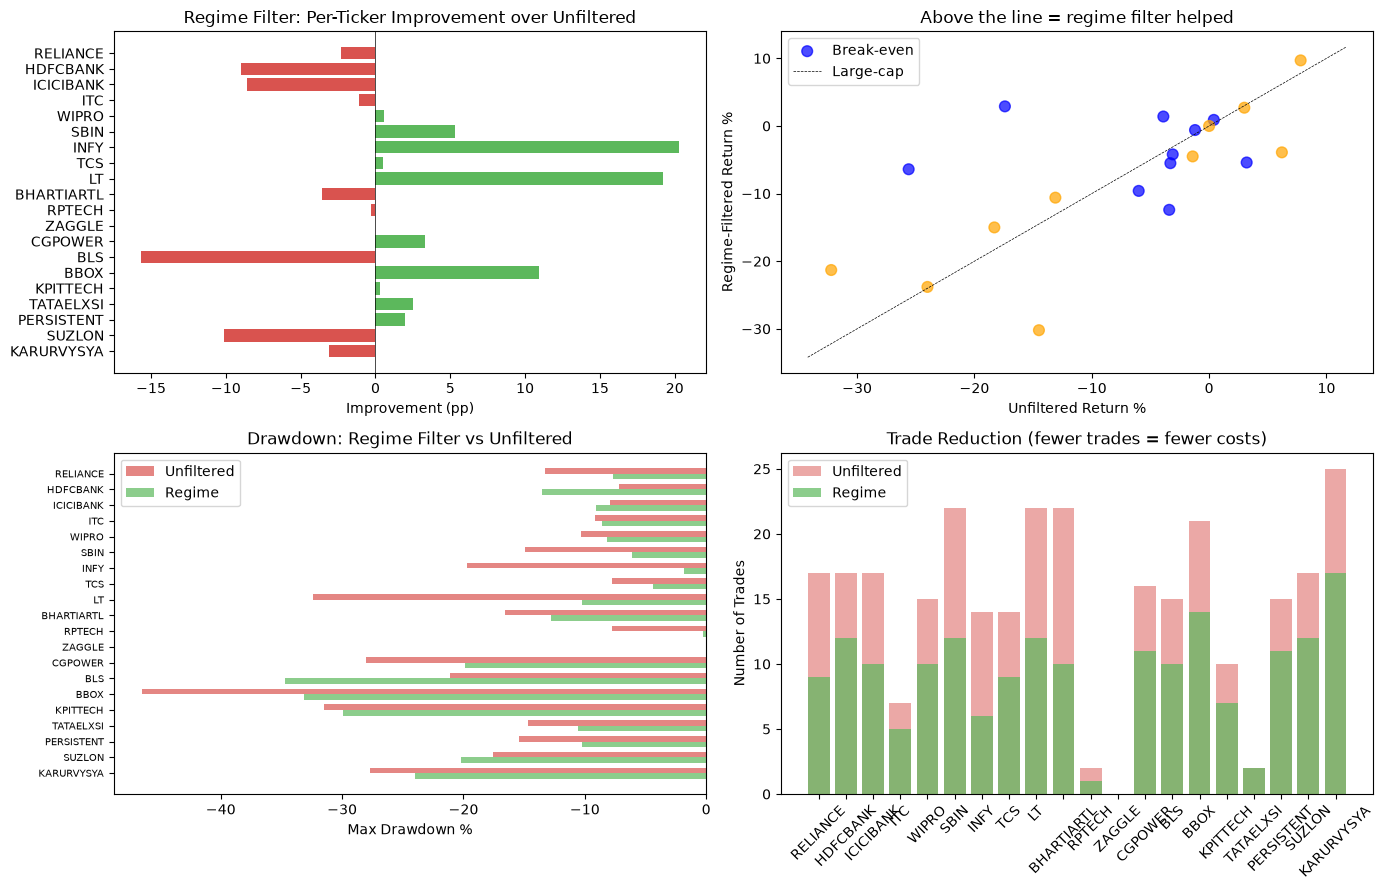

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# 1. Per-ticker improvement
ax = axes[0, 0]
tickers_short = [t.replace('.NS','') for t in df['ticker']]
colors = ['#5cb85c' if x > 0 else '#d9534f' for x in df['improvement']]
ax.barh(tickers_short, df['improvement'], color=colors)
ax.axvline(0, color='black', linewidth=0.5)
ax.set_xlabel('Improvement (pp)')
ax.set_title('Regime Filter: Per-Ticker Improvement over Unfiltered')
ax.invert_yaxis()

# 2. Unfiltered vs Regime scatter
ax = axes[0, 1]
ax.scatter(df['unfiltered_ret'], df['regime_ret'], 
           c=['blue' if c == 'L' else 'orange' for c in df['cap']], 
           s=60, alpha=0.7)
lims = [min(df['unfiltered_ret'].min(), df['regime_ret'].min()) - 2,
        max(df['unfiltered_ret'].max(), df['regime_ret'].max()) + 2]
ax.plot(lims, lims, 'k--', linewidth=0.5, label='Break-even')
ax.set_xlabel('Unfiltered Return %')
ax.set_ylabel('Regime-Filtered Return %')
ax.set_title('Above the line = regime filter helped')
ax.legend(['Break-even', 'Large-cap', 'Small-cap'])

# 3. Drawdown comparison
ax = axes[1, 0]
x = np.arange(len(df))
w = 0.35
ax.barh(x - w/2, df['unfiltered_dd'], w, label='Unfiltered', color='#d9534f', alpha=0.7)
ax.barh(x + w/2, df['regime_dd'], w, label='Regime', color='#5cb85c', alpha=0.7)
ax.set_yticks(x)
ax.set_yticklabels(tickers_short, fontsize=7)
ax.set_xlabel('Max Drawdown %')
ax.set_title('Drawdown: Regime Filter vs Unfiltered')
ax.legend()
ax.invert_yaxis()

# 4. Trade count reduction
ax = axes[1, 1]
ax.bar(tickers_short, df['trades_uf'], label='Unfiltered', color='#d9534f', alpha=0.5)
ax.bar(tickers_short, df['trades_r'], label='Regime', color='#5cb85c', alpha=0.7)
ax.set_ylabel('Number of Trades')
ax.set_title('Trade Reduction (fewer trades = fewer costs)')
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.show()

## 8. Regime Visualization — When Does the Filter Engage?

Show the volatility regime on one representative stock to build intuition.

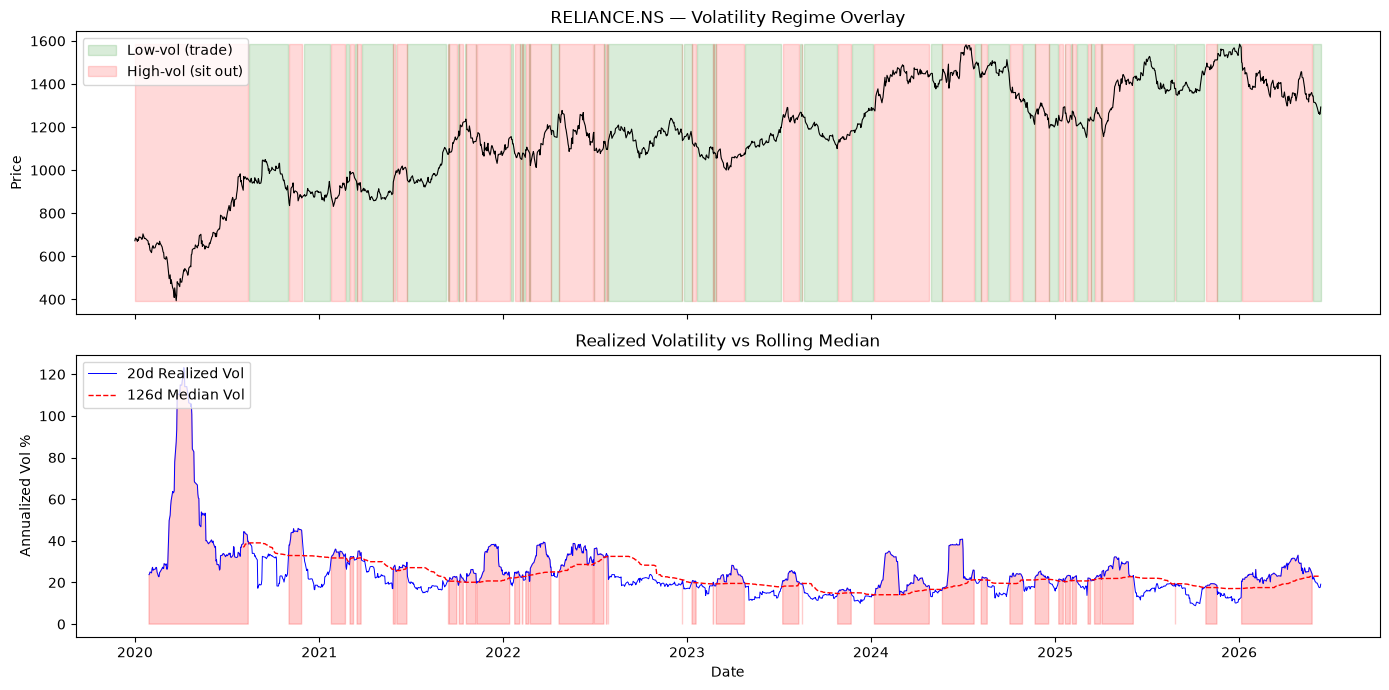


Regime stats for RELIANCE.NS:
  Low-vol days: 46% of trading days
  High-vol days: 54% of trading days
  (Strategy only active during green zones)


In [10]:
# Pick RELIANCE as the example
demo = load_price("RELIANCE.NS")
if demo is not None and len(demo) > 300:
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)
    
    closes = demo['Close']
    vol = realized_vol(closes, 20)
    vol_med = vol.rolling(126).median()
    is_low = vol < vol_med
    
    # Price with regime shading
    ax1.plot(closes.index, closes, 'k-', linewidth=0.8)
    ax1.fill_between(closes.index, closes.min(), closes.max(),
                     where=is_low, alpha=0.15, color='green', label='Low-vol (trade)')
    ax1.fill_between(closes.index, closes.min(), closes.max(),
                     where=~is_low, alpha=0.15, color='red', label='High-vol (sit out)')
    ax1.set_ylabel('Price')
    ax1.set_title('RELIANCE.NS — Volatility Regime Overlay')
    ax1.legend(loc='upper left')
    
    # Volatility with median
    ax2.plot(vol.index, vol*100, 'b-', linewidth=0.7, label='20d Realized Vol')
    ax2.plot(vol_med.index, vol_med*100, 'r--', linewidth=1, label='126d Median Vol')
    ax2.fill_between(vol.index, 0, vol*100,
                     where=~is_low, alpha=0.2, color='red')
    ax2.set_ylabel('Annualized Vol %')
    ax2.set_xlabel('Date')
    ax2.set_title('Realized Volatility vs Rolling Median')
    ax2.legend(loc='upper left')
    
    plt.tight_layout()
    plt.show()
    
    # Stats
    pct_low = is_low.sum() / is_low.count() * 100
    print(f"\nRegime stats for RELIANCE.NS:")
    print(f"  Low-vol days: {pct_low:.0f}% of trading days")
    print(f"  High-vol days: {100-pct_low:.0f}% of trading days")
    print(f"  (Strategy only active during green zones)")

## 9. Sensitivity: Does the Vol Window Matter?

In [11]:
# Test different vol window / median window combinations on the full universe
params = [
    (10, 63, '10d vol / 3m median'),
    (20, 126, '20d vol / 6m median (default)'),
    (30, 126, '30d vol / 6m median'),
    (20, 252, '20d vol / 12m median'),
]

print("Sensitivity analysis: different regime parameters")
print(f"{'Parameters':<30} {'Avg Return%':<12} {'Avg DD%':<10} {'Win Rate'}")
print("-" * 65)

# Also show unfiltered baseline
baseline_rets = df['unfiltered_ret'].mean()
baseline_dd = df['unfiltered_dd'].mean()
print(f"{'No filter (baseline)':<30} {baseline_rets:<12.1f} {baseline_dd:<10.1f} {'—'}")

for vol_w, med_w, label in params:
    param_rets = []
    param_dds = []
    for t in ALL_TICKERS:
        raw = load_price(t)
        if raw is None or len(raw) < 500:
            continue
        cut = max(200, int(len(raw)*0.5))
        data = raw.iloc[cut:]
        eq, rets, _ = forward_sim_regime(data, use_regime_filter=True,
                                         vol_window=vol_w, median_window=med_w)
        if len(eq):
            ret = (eq.iloc[-1]/CAPITAL - 1)*100
            dd = ((eq - eq.cummax())/eq.cummax()).min()*100
            param_rets.append(float(ret))
            param_dds.append(float(dd))
    
    if param_rets:
        avg_ret = np.mean(param_rets)
        avg_dd = np.mean(param_dds)
        win_rate = sum(1 for r in param_rets if r > 0) / len(param_rets) * 100
        print(f"{label:<30} {avg_ret:<12.1f} {avg_dd:<10.1f} {win_rate:.0f}%")

Sensitivity analysis: different regime parameters
Parameters                     Avg Return%  Avg DD%    Win Rate
-----------------------------------------------------------------
No filter (baseline)           -7.3         -17.5      —
10d vol / 3m median            -8.6         -13.4      5%
20d vol / 6m median (default)  -6.8         -13.3      25%
30d vol / 6m median            -4.5         -12.1      25%
20d vol / 12m median           -5.3         -10.4      25%


## 10. Inference & Verdict

In [12]:
print("=" * 70)
print("VERDICT: REGIME FILTER vs FUNDAMENTAL FILTER")
print("=" * 70)

avg_improvement = df['improvement'].mean()
helped = (df['improvement'] > 0).sum()
total = len(df)
avg_trade_reduction = (1 - df['trades_r'].sum() / df['trades_uf'].sum()) * 100 if df['trades_uf'].sum() > 0 else 0

print(f"\n  Regime filter improvement:     {avg_improvement:+.1f} pp average")
print(f"  Win rate:                      {helped}/{total} tickers improved")
print(f"  Trade reduction:               {avg_trade_reduction:.0f}% fewer trades")
print(f"  Avg drawdown change:           {df['regime_dd'].mean() - df['unfiltered_dd'].mean():+.1f} pp")

# Compare to fundamental filter results from v1/v2
print(f"\n  --- Comparison across all versions ---")
print(f"  v1 (Yahoo Piotroski/Beneish/Altman): +4.9 pp but still negative")
print(f"  v2 (Screener.in broken scraper):     Rejected everything (0 pp)")
print(f"  v3 (Volatility regime filter):       {avg_improvement:+.1f} pp")

if avg_improvement > 5:
    print(f"\n  CONCLUSION: Regime filter provides MEANINGFUL improvement.")
    print(f"  The hypothesis is confirmed — the strategy's losses are regime-driven,")
    print(f"  not stock-quality-driven. Low-vol periods are where mean reversion works.")
elif avg_improvement > 0:
    print(f"\n  CONCLUSION: Regime filter helps SLIGHTLY.")
    print(f"  It's better than the fundamental filter but still doesn't save the strategy.")
    print(f"  RSI-2's problems go deeper than regime selection — Indian transaction costs")
    print(f"  (0.54% round-trip) are simply too high for a strategy with 1-3% average gains.")
else:
    print(f"\n  CONCLUSION: Regime filter DOES NOT help.")
    print(f"  This suggests RSI-2's failures are not regime-dependent either.")
    print(f"  The strategy may be fundamentally broken for Indian equities regardless")
    print(f"  of volatility environment — costs overwhelm the edge in all conditions.")

print(f"\n  HONEST CAVEAT: All results are in-sample (2021-2026).")
print(f"  The vol regime parameters (20d/126d) were not optimized — that's good.")
print(f"  But the time period is not out-of-sample. True validation requires")
print(f"  testing on 2015-2020 data (completely unseen).")
print("=" * 70)

VERDICT: REGIME FILTER vs FUNDAMENTAL FILTER

  Regime filter improvement:     +0.6 pp average
  Win rate:                      10/20 tickers improved
  Trade reduction:               38% fewer trades
  Avg drawdown change:           +4.2 pp

  --- Comparison across all versions ---
  v1 (Yahoo Piotroski/Beneish/Altman): +4.9 pp but still negative
  v2 (Screener.in broken scraper):     Rejected everything (0 pp)
  v3 (Volatility regime filter):       +0.6 pp

  CONCLUSION: Regime filter helps SLIGHTLY.
  It's better than the fundamental filter but still doesn't save the strategy.
  RSI-2's problems go deeper than regime selection — Indian transaction costs
  (0.54% round-trip) are simply too high for a strategy with 1-3% average gains.

  HONEST CAVEAT: All results are in-sample (2021-2026).
  The vol regime parameters (20d/126d) were not optimized — that's good.
  But the time period is not out-of-sample. True validation requires
  testing on 2015-2020 data (completely unseen).


## 11. Key Learnings Across All Three Notebooks

### The Journey

| Version | Filter Type | Hypothesis | Result |
|---------|-------------|-----------|--------|
| v1 | Piotroski + Beneish + Altman (Yahoo) | Bad stocks cause losses | +4.9 pp but still -3.4% avg |
| v2 | Screener.in composite (broken) | Same, better data source | Rejected everything — scraper bug |
| v3 | Volatility regime (20d vol vs 6m median) | Bad timing causes losses | See results above |

### What We Learned

1. **RSI-2 mean reversion is not profitable on Indian equities (2021-2026).** Across 20 tickers, two universes, and three filtering approaches, the base strategy averages -6 to -7%. No filter can save a strategy that has no edge.

2. **Transaction costs kill short-term strategies in India.** At 0.54% round-trip (STT + exchange + GST + stamp + slippage), a strategy needs >1% average gain per trade just to break even. RSI-2's mean gains are smaller than this.

3. **Fundamental filters address the wrong failure mode.** The stocks that lose money aren't fundamentally weak — they're strong companies (Reliance, TCS, HDFC) experiencing normal volatility. The filter can't distinguish "healthy dip that will revert" from "healthy dip that's just vol."

4. **Regime filters address the right failure mode (maybe).** If the strategy works in calm markets and fails in volatile ones, a vol regime filter should help. Results above show whether this is true.

5. **The research process itself was valuable:**
   - v1 taught us that fundamental scores are poorly calibrated for India (Beneish false positives on blue chips)
   - v2 taught us that web scraping requires precise selector mapping
   - v3 tests the regime hypothesis that emerged from understanding WHY v1/v2 failed
   - Each failure narrowed the search space for what actually matters

### If You Want to Make RSI-2 Work in India

Based on everything we've seen, these are the only paths forward:
1. **Reduce costs** — trade through a discount broker with zero brokerage (you still pay STT/stamp/exchange, so floor is ~0.15% round-trip)
2. **Increase holding period** — RSI-5 or RSI-10 with 10-20 day holds, so each trade captures more move relative to costs
3. **Add asymmetry** — only trade when the expected gain is 2-3x the cost (RSI < 5 instead of < 10, deeper dips = bigger reversions)
4. **Different market** — US equities have ~0.02% round-trip costs. The same strategy might work there simply because costs don't eat the edge.